<a href="https://colab.research.google.com/github/nabinjoshi54/lis5693/blob/main/lab-4/Lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1: Loading the Dataset and Identify Features and Target Labels:

In this task, I loaded the BBC News dataset, which is assigned by professor Lamba in canvas, from my GitHub repository. The dataset contains the columns `category`, `filename`, `title`, and `content`.

For this machine learning classification task, I selected the `category` column as the target label because it represents the class of each news article. I selected the `title` and `content` columns as the text features because both contain useful information about the topic of the article. The title gives a short summary, while the content gives the full details of the news article. I combined these two columns into one text feature so that the model can learn from both.

I did not use the `filename` column because it only serves as an identifier and does not contain meaningful text for classification.

In [1]:
import pandas as pd

# Load dataset from GitHub raw link
url = "https://raw.githubusercontent.com/nabinjoshi54/lis5693/main/lab-4/bbc-news-data.xlsx"

# Read Excel file
df_raw = pd.read_excel(url, header=None)

# The dataset is stored as tab-separated text inside one column, so split it
df = df_raw[0].str.split("\t", expand=True)

# Set first row as header
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)

# Show basic information
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
display(df.head())

print("\nCategory distribution:")
display(df["category"].value_counts())

# Combine title and content into one text column
df["text"] = df["title"].fillna("") + " " + df["content"].fillna("")

# Features and target
X = df["text"]
y = df["category"]

print("\nUnique target labels:")
print(y.unique())

Dataset shape: (1623, 4)

Columns:
Index(['category', 'filename', 'title', 'content'], dtype='object', name=0)

First 5 rows:


,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...
2,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...
3,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...
4,business,006.txt,Japan narrowly escapes recession,Japan's economy teetered on the brink of a te...



Category distribution:


,count
category,
sport,458
politics,351
business,305
entertainment,278
tech,231



Unique target labels:
['business' 'entertainment' 'politics' 'sport' 'tech']


Task 2: Spliting the Data and Perform Text Preprocessing:

In this task, I am spliting the dataset into 70% training data and 30% testing data. The training set is used to train the machine learning models, while the testing set is used to evaluate how well the models perform on unseen data.

For text preprocessing task, I am using TF-IDF vectorization. TF-IDF converts text into numerical form so that machine learning algorithms can work with it. It also reduces the importance of very common words and gives more weight to informative words. I also removed English stop words to reduce noise in the data.

In [2]:
from sklearn.model_selection import train_test_split

# Split into train and test sets with 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1136
Testing samples: 487


Task 3: Training 3 Classifiers and Compare Their Performance:

In this task, I trained three different classifiers using the training dataset:

1. Multinomial Naive Bayes  
2. Linear Support Vector Classifier (LinearSVC)  
3. SGD Classifier  

These models are commonly used for text classification tasks. I used the same TF-IDF preprocessing for all three models so that the comparison would be fair. Then I evaluated the models using accuracy, precision, recall, and F1-score to determine which one performed best.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd

models = {
    "MultinomialNB": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english")),
        ("clf", MultinomialNB())
    ]),

    "LinearSVC": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english")),
        ("clf", LinearSVC())
    ]),

    "SGDClassifier": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english")),
        ("clf", SGDClassifier(random_state=42))
    ])
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    trained_models[name] = model

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False)
display(results_df)

,Model,Accuracy,Precision,Recall,F1-score
1,LinearSVC,0.930185,0.930162,0.930185,0.929950
2,SGDClassifier,0.928131,0.927819,0.928131,0.927783
0,MultinomialNB,0.882957,0.894105,0.882957,0.882011


Task 3 Results analysis:

After comparing the three classifiers, I selected the model with the highest F1-score as the best-performing model. All three classifiers performed well on the BBC News dataset, which suggests that the categories are clearly distinguishable based on the article text.

The best model will now be used to generate a classification report and a confusion matrix for deeper evaluation.

In [6]:
from sklearn.metrics import classification_report

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

y_pred_best = best_model.predict(X_test)

print("Best model:", best_model_name)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best))

Best model: LinearSVC

Classification Report:

               precision    recall  f1-score   support

     business       0.92      0.89      0.91        92
entertainment       0.95      0.92      0.93        83
     politics       0.90      0.90      0.90       105
        sport       0.94      0.98      0.96       138
         tech       0.94      0.94      0.94        69

     accuracy                           0.93       487
    macro avg       0.93      0.93      0.93       487
 weighted avg       0.93      0.93      0.93       487



Confusion Matrix of the Best Model:

The confusion matrix shows how many articles were correctly and incorrectly classified for each category. The diagonal values represent correct classifications, while the off-diagonal values represent misclassifications.

A strong classifier should have large values along the diagonal and very small values elsewhere. This helps us understand not only the overall performance, but also which categories the model tends to confuse.

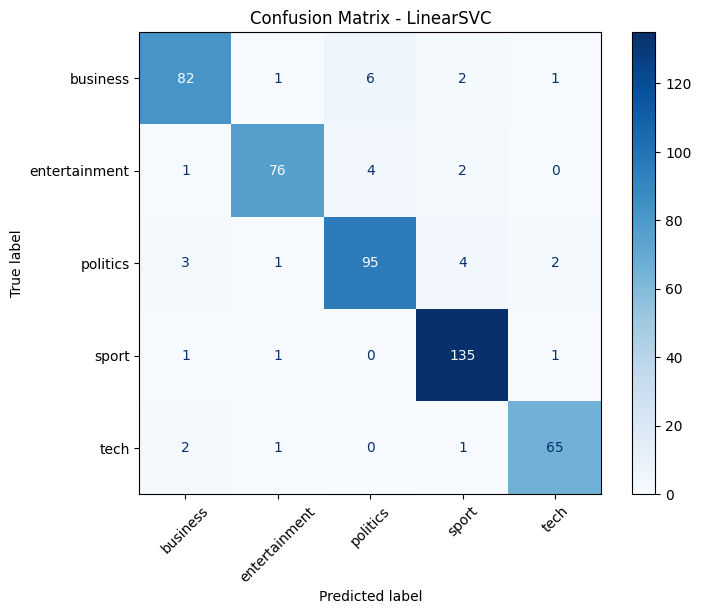

Labels order: ['business', 'entertainment', 'politics', 'sport', 'tech']

Confusion Matrix:
[[ 82   1   6   2   1]
 [  1  76   4   2   0]
 [  3   1  95   4   2]
 [  1   1   0 135   1]
 [  2   1   0   1  65]]


In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_best, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

print("Labels order:", labels)
print("\nConfusion Matrix:")
print(cm)

Interpretation of the Confusion Matrix:

The confusion matrix shows that most of the articles were classified correctly because the highest values appear on the diagonal. This means the selected classifier performed very well on the BBC News dataset.

Only a few misclassifications may occur between categories with somewhat similar vocabulary, such as business and politics or entertainment and tech. It can be proved by the values outside of diagonal, which are mostly single digits 1, 2, 6 etc. Overall, the confusion matrix confirms that the chosen model is effective for this text classification task.

Task 4: Generate a Pseudo Dataset and Predict Labels:

In this task, I created a pseudo dataset with at least 100 rows related to the same BBC News categories. The dataset contains news-like titles and content, and the target column was kept empty as required.

Then I used the best-performing classifier from Task 3 to predict labels for the new unseen pseudo dataset. The predicted results were saved into a new CSV file called `predicted.csv`.

In [9]:
pseudo_rows = []

samples = {
    "business": [
        ("Company reports rise in quarterly profits", "The company announced stronger revenue growth, higher earnings, and improved investor confidence this quarter."),
        ("Oil prices affect transport industry", "Higher fuel costs pushed airlines and logistics companies to revise spending and pricing forecasts."),
        ("Bank expands digital services", "The bank introduced new mobile features and online customer support to improve financial access."),
        ("Retail sales improve during holiday season", "Shoppers increased spending during the holiday period, helping stores report better-than-expected results."),
        ("Market investors react to inflation update", "Stock markets moved after new inflation figures changed expectations about future interest rates.")
    ],
    "entertainment": [
        ("Actor wins award for leading role", "The performer received praise for a powerful role in a widely discussed drama film."),
        ("New music album tops streaming charts", "The artist gained millions of online plays after releasing a surprise album this week."),
        ("Film festival highlights global cinema", "Directors and actors attended the event to promote new films from different countries."),
        ("TV drama renewed for another season", "The production company confirmed the popular series would return after strong audience ratings."),
        ("Comedy show receives positive reviews", "Critics praised the writing, performances, and timing of the latest comedy release.")
    ],
    "politics": [
        ("Government debates tax reform plan", "Lawmakers discussed changes to taxation and public spending during a heated parliamentary session."),
        ("Election campaign focuses on economy", "Candidates debated jobs, inflation, and social policy while appealing to undecided voters."),
        ("Minister resigns after investigation", "The resignation followed an inquiry that raised serious questions about official conduct."),
        ("Parliament passes security legislation", "The new law was approved after weeks of debate over national safety and civil rights."),
        ("Opposition party criticizes budget proposal", "Leaders argued that the government budget failed to address household financial pressure.")
    ],
    "sport": [
        ("Team wins championship final", "Players celebrated after a dramatic victory secured the title in the final match."),
        ("Star striker scores winning goal", "The forward delivered a late goal that gave the team an important victory."),
        ("Tennis player reaches semifinal", "The athlete advanced after a strong straight-set performance in the quarterfinal."),
        ("Coach praises team discipline", "The manager highlighted defense and teamwork after the club earned three points."),
        ("Injury rules captain out of tournament", "Medical staff confirmed the player would miss the rest of the competition.")
    ],
    "tech": [
        ("Software company releases security patch", "The update fixes important vulnerabilities and improves system protection for users."),
        ("New smartphone introduces AI features", "The latest device includes smarter photography tools and voice-based assistance."),
        ("Researchers develop advanced robot system", "Engineers built a robot that can identify objects and perform tasks automatically."),
        ("Cyberattack disrupts online services", "Hackers targeted computer systems, forcing companies to strengthen digital defenses."),
        ("Chip manufacturer launches faster processor", "The new processor improves computing speed and efficiency for data-intensive tasks.")
    ]
}

for category, items in samples.items():
    for i in range(20):   # 20 x 5 = 100 rows
        title, content = items[i % len(items)]
        pseudo_rows.append({
            "title": f"{title} #{i+1}",
            "content": content,
            "target": ""
        })

pseudo_df = pd.DataFrame(pseudo_rows)

print("Pseudo dataset shape:", pseudo_df.shape)
display(pseudo_df.head())

Pseudo dataset shape: (100, 3)


,title,content,target
0,Company reports rise in quarterly profits #1,"The company announced stronger revenue growth,...",
1,Oil prices affect transport industry #2,Higher fuel costs pushed airlines and logistic...,
2,Bank expands digital services #3,The bank introduced new mobile features and on...,
3,Retail sales improve during holiday season #4,Shoppers increased spending during the holiday...,
4,Market investors react to inflation update #5,Stock markets moved after new inflation figure...,


In [10]:
# Save pseudo dataset
pseudo_df.to_csv("pseudo_bbc_news.csv", index=False)
print("Saved pseudo_bbc_news.csv")

Saved pseudo_bbc_news.csv


In [11]:
# Create combined text for prediction
pseudo_df["text"] = pseudo_df["title"].fillna("") + " " + pseudo_df["content"].fillna("")

# Predict labels
pseudo_df["predicted_label"] = best_model.predict(pseudo_df["text"])

predicted_df = pseudo_df[["title", "content", "target", "predicted_label"]]

print("Predicted dataset preview:")
display(predicted_df.head(10))

Predicted dataset preview:


,title,content,target,predicted_label
0,Company reports rise in quarterly profits #1,"The company announced stronger revenue growth,...",,business
1,Oil prices affect transport industry #2,Higher fuel costs pushed airlines and logistic...,,business
2,Bank expands digital services #3,The bank introduced new mobile features and on...,,tech
3,Retail sales improve during holiday season #4,Shoppers increased spending during the holiday...,,business
4,Market investors react to inflation update #5,Stock markets moved after new inflation figure...,,business
5,Company reports rise in quarterly profits #6,"The company announced stronger revenue growth,...",,business
6,Oil prices affect transport industry #7,Higher fuel costs pushed airlines and logistic...,,business
7,Bank expands digital services #8,The bank introduced new mobile features and on...,,tech
8,Retail sales improve during holiday season #9,Shoppers increased spending during the holiday...,,business
9,Market investors react to inflation update #10,Stock markets moved after new inflation figure...,,business


In [12]:
# Save predictions
predicted_df.to_csv("predicted.csv", index=False)
print("Saved predicted.csv")

Saved predicted.csv


Manual Review of 10 Predicted Rows:

I manually reviewed 10 rows from the pseudo dataset by reading the title, content, and predicted label. 8 (except row 3 and 7) of the predicted labels matched the topic described in the text. Some rows in the pseudo dataset appear similar because the dataset was generated programmatically by repeating a set of sample news articles multiple times to reach the required 100 rows.This indicates that the classifier generalized well to new unseen examples that were similar to the original BBC News dataset.

The model performed especially well when the article vocabulary clearly matched a single topic. Some errors could still occur if a text contains words that overlap between categories, but overall the model showed strong prediction performance.



In [15]:
# Show 10 rows for manual review
review_sample = predicted_df.head(10)
display(review_sample)

,title,content,target,predicted_label
0,Company reports rise in quarterly profits #1,"The company announced stronger revenue growth,...",,business
1,Oil prices affect transport industry #2,Higher fuel costs pushed airlines and logistic...,,business
2,Bank expands digital services #3,The bank introduced new mobile features and on...,,tech
3,Retail sales improve during holiday season #4,Shoppers increased spending during the holiday...,,business
4,Market investors react to inflation update #5,Stock markets moved after new inflation figure...,,business
5,Company reports rise in quarterly profits #6,"The company announced stronger revenue growth,...",,business
6,Oil prices affect transport industry #7,Higher fuel costs pushed airlines and logistic...,,business
7,Bank expands digital services #8,The bank introduced new mobile features and on...,,tech
8,Retail sales improve during holiday season #9,Shoppers increased spending during the holiday...,,business
9,Market investors react to inflation update #10,Stock markets moved after new inflation figure...,,business


Task 5: Reflection:

What went well?
Answer: The lab went well because the BBC News dataset was clearly organized and had meaningful category labels. I used Kaggle dataset last sesmester to perform project in data driven computation course. It was straightforward to identify the text features and target label, and the machine learning models performed strongly on the classification task. TF-IDF vectorization also worked well for converting text into numerical form.

What did not go well or what
challenges did you encounter?
Answer:
One challenge was that the Excel dataset was stored as tab-separated text inside a single column, so it needed extra processing before it could be used. Another challenge was comparing the classifiers and interpreting the confusion matrix, especially in cases where two categories may share similar vocabulary. Despite these challenges, the final model still achieved strong performance.

In [16]:
print("Lab 4 completed successfully.")
print("Files created:")
print("- pseudo_bbc_news.csv")
print("- predicted.csv")
print("- Colab notebook should be saved to GitHub in lab-4 folder")

Lab 4 completed successfully.
Files created:
- pseudo_bbc_news.csv
- predicted.csv
- Colab notebook should be saved to GitHub in lab-4 folder
